In [1]:
#Imports
import numpy as np
import pandas as pd
import polars as pl 


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline


import seaborn as sns

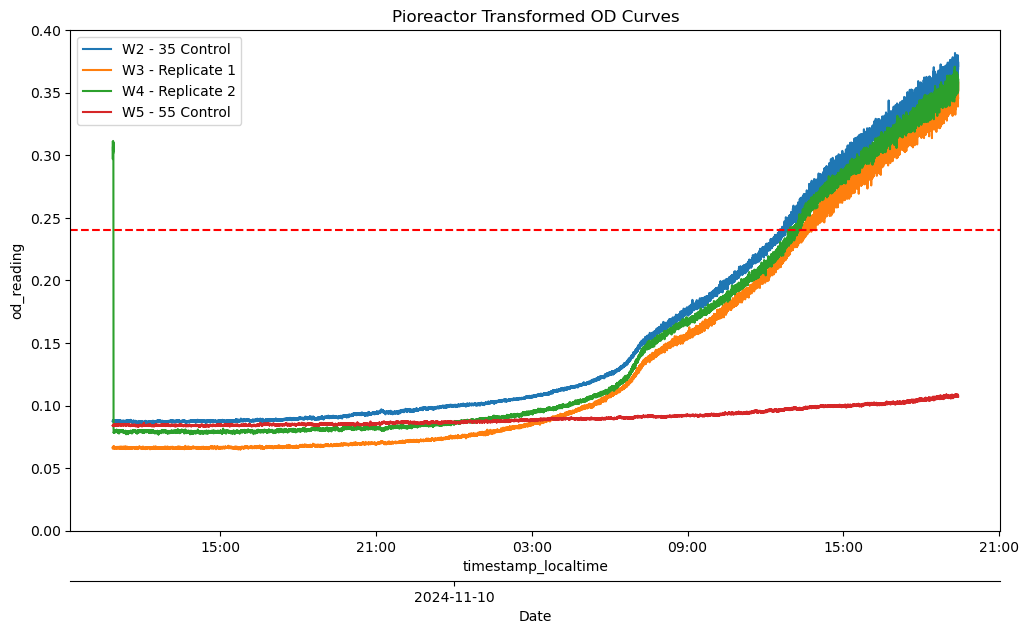

In [2]:
# Load DataFrame
df = pl.scan_csv('/Users/jackson/Library/CloudStorage/OneDrive-UW/University of Washington/deming_lab/switching_salinity/od_logs/11_08_2024-od_readings-20241110192513.csv')

# Dictionary to map 'Pioreactor name' to new values
name_dict = {
    'worker2': 'W2 - 35 Control',
    'worker3': 'W3 - Replicate 1',
    'worker4': 'W4 - Replicate 2',
    'worker5': 'W5 - 55 Control'
}

# Define the corresponding transformations for each condition
equations = {
    "W2 - 35 Control": (1.325017724, 0.08205328), 
    "W3 - Replicate 1": (2.184707514,0.062397906), 
    "W4 - Replicate 2": (2.235238563,0.07304782), 
    "W5 - 55 Control": (1.155349883, 0.080476914), 
}

# Replace values in 'Pioreactor name' column using the dictionary
df = df.with_columns(pl.col("pioreactor_unit").replace_strict(name_dict))
all_dfs = []

for pioreactor_unit in name_dict.values():  # This could be more effeciently done with a group_by
    temp_df = df.filter(pl.col("pioreactor_unit") == pioreactor_unit)
    a, b = equations[pioreactor_unit]
    temp_df = temp_df.with_columns(pl.col("od_reading") * a+b)

    all_dfs.append(temp_df)

df = pl.concat(all_dfs).collect()


# Convert 'timestamp_localtime' to datetime format with strict=False
df = df.with_columns(
    pl.col("timestamp_localtime").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False)
)

# Plotting the growth curves using the new 'Transformed OD' column
f, ax = plt.subplots(figsize=(12, 6.5))
sns.lineplot(x="timestamp_localtime", y="od_reading", hue="pioreactor_unit",
             palette='tab10', markersize=8, sizes=(1, 8), data=df.to_pandas(), ax=ax)

# Set major ticks to every 6 hours
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# Create a secondary x-axis for date display
secax = ax.secondary_xaxis(-0.1)
secax.xaxis.set_major_locator(mdates.DayLocator())
secax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
secax.set_xlabel("Date")

# Customize plot
plt.legend()
plt.axhline(y=0.24, color='r', linestyle='--')
ax.set_title('Pioreactor Transformed OD Curves')
ax.set_ylim(0, 0.4)
plt.show()



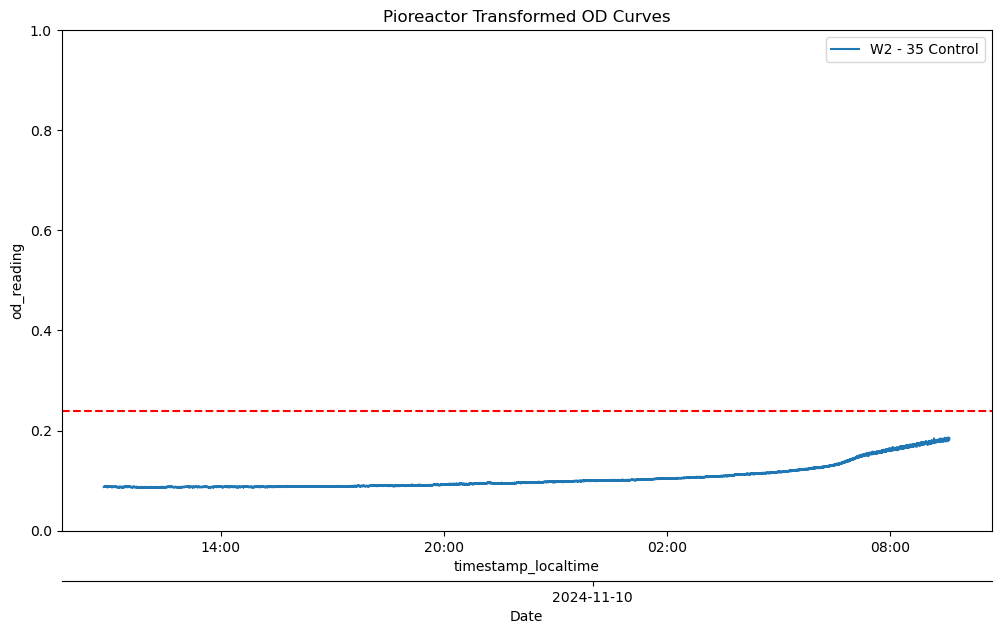

In [3]:
# Load DataFrame
df = pl.scan_csv('/Users/jackson/Downloads/export_11_08_2024_20241110093542/11_08_2024-pioreactor_unit_activity_data-worker2-20241110093543.csv')

# Dictionary to map 'Pioreactor name' to new values
name_dict = {
    'worker2': 'W2 - 35 Control',
    'worker3': 'W3 - Replicate 1',
    'worker4': 'W4 - Replicate 2',
    'worker5': 'W5 - 55 Control'
}

# Define the corresponding transformations for each condition
equations = {
    "W2 - 35 Control": (1.325017724, 0.08205328), 
    "W3 - Replicate 1": (2.184707514,0.062397906), 
    "W4 - Replicate 2": (2.235238563,0.07304782), 
    "W5 - 55 Control": (1.155349883, 0.080476914), 
}

# Replace values in 'Pioreactor name' column using the dictionary
df = df.with_columns(pl.col("pioreactor_unit").replace_strict(name_dict))
all_dfs = []

for pioreactor_unit in name_dict.values():  # This could be more effeciently done with a group_by
    temp_df = df.filter(pl.col("pioreactor_unit") == pioreactor_unit)
    a, b = equations[pioreactor_unit]
    temp_df = temp_df.with_columns(pl.col("od_reading") * a+b)

    all_dfs.append(temp_df)

df = pl.concat(all_dfs).collect()


# Convert 'timestamp_localtime' to datetime format with strict=False
df = df.with_columns(
    pl.col("timestamp_localtime").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False)
)

# Plotting the growth curves using the new 'Transformed OD' column
f, ax = plt.subplots(figsize=(12, 6.5))
sns.lineplot(x="timestamp_localtime", y="od_reading", hue="pioreactor_unit",
             palette='tab10', markersize=8, sizes=(1, 8), data=df.to_pandas(), ax=ax)

# Set major ticks to every 6 hours
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# Create a secondary x-axis for date display
secax = ax.secondary_xaxis(-0.1)
secax.xaxis.set_major_locator(mdates.DayLocator())
secax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
secax.set_xlabel("Date")

# Customize plot
plt.legend()
plt.axhline(y=0.24, color='r', linestyle='--')
ax.set_title('Pioreactor Transformed OD Curves')
ax.set_ylim(0,1)
plt.show()

